# Kwant — Theory and Practice · Chapter 8
## Topology in one dimension — SSH, Kitaev, the Majorana nanowire

*Part II · Sections 17–19 · Figures 35–46* &nbsp;·&nbsp; [← Chapter 7](07_Solvers_Pitfalls_and_Exercises_I.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 9 →](09_Chern_Numbers.ipynb)

### In this chapter

- **Part II — Topological matter**
- [17. The SSH chain — the simplest topological insulator](#17.-The-SSH-chain-—-the-simplest-topological-insulator)
- [18. The Kitaev chain — Majorana zero modes](#18.-The-Kitaev-chain-—-Majorana-zero-modes)
- [19. The Majorana nanowire — Kitaev physics in a real device](#19.-The-Majorana-nanowire-—-Kitaev-physics-in-a-real-device)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 35–46, so the counter starts at 34.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [34]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
# Part II — Topological matter

Everything below applies the machinery of Part I to the flagship models of
topological condensed matter, in one, two and three dimensions.  Each section
follows the same arc: *theory → a numerical topological invariant → edge or
surface states → a transport signature* (where transport is meaningful).

Two computational ideas do most of the work:

* **Berry phases on a discretized Brillouin zone.**  Wilson loops (products of
  overlap matrices of occupied states) give polarizations, Wannier centers and,
  via the Fukui–Hatsugai–Suzuki plaquette formula, Chern numbers that are
  *exactly* integer even on coarse grids.
* **Bulk–boundary correspondence in transport.**  A nonzero bulk invariant
  forces gapless edge/surface states, which Kwant sees directly as quantized,
  disorder-immune conductance.

Sources this part draws on: the Delft course
[topocondmat.org](https://topocondmat.org) (Kwant-based notebooks),
the [PythTB examples](https://www.physics.rutgers.edu/pythtb/examples.html)
(Berry-phase computations), Asbóth, Oroszlány & Pályi,
*A Short Course on Topological Insulators* (Springer 2016), and the original
papers cited in each section.

**Where the invariants come from.**  Every quantised number computed in this
part descends from one object: the Berry phase of Bloch states [M. V. Berry,
Proc. R. Soc. A **392**, 45 (1984)].  Integrated over a 2D Brillouin zone its
curvature gives the Chern number of TKNN [Thouless, Kohmoto, Nightingale &
den Nijs, PRL **49**, 405 (1982)], which *is* the Hall conductance; restricted
to a loop it gives the Zak phase / electric polarization; with time reversal
it collapses to the $\mathbb{Z}_2$ index; nested inside a Wilson loop it
yields multipole moments.  Which invariant a Hamiltonian can carry is fixed
by its antiunitary symmetries alone — the *tenfold way* classification
[Altland-Zirnbauer; see Chiu, Teo, Schnyder & Ryu, RMP **88**, 035005
(2016)].

*General reviews:* Hasan & Kane, RMP **82**, 3045 (2010); Qi & Zhang, RMP
**83**, 1057 (2011); Xiao, Chang & Niu, RMP **82**, 1959 (2010) (Berry
phases); Bernevig & Hughes, *Topological Insulators and Topological
Superconductors* (Princeton, 2013); Asbóth, Oroszlány & Pályi (Springer,
2016).  Beyond solids: Cooper, Dalibard & Spielman, RMP **91**, 015005
(2019) (ultracold atoms); Ozawa *et al.*, RMP **91**, 015006 (2019)
(photonics).


---
## 17. The SSH chain — the simplest topological insulator

The Su–Schrieffer–Heeger model [PRL **42**, 1698 (1979)] is a dimerized chain:
two sites per cell, alternating hoppings $t_1$ (intra-cell) and $t_2$
(inter-cell),

$$H(k) = \begin{pmatrix} 0 & q(k) \\ q^*(k) & 0 \end{pmatrix},
\qquad q(k) = t_1 + t_2 e^{ik}.$$

Chiral (sublattice) symmetry $\sigma_z H \sigma_z = -H$ makes the *winding
number* of $q(k)$ around the origin a quantized invariant:

$$\nu = \frac{1}{2\pi i}\oint dk\, \frac{d}{dk}\log q(k) =
\begin{cases} 0 & t_1 > t_2 \text{ (trivial)}\\ 1 & t_1 < t_2 \text{ (topological)}\end{cases}$$

Equivalently the Zak phase (Berry phase of the filled band across the BZ) is
$0$ or $\pi$.  Bulk–boundary correspondence: $\nu = 1$ forces one zero-energy
state per end, exponentially localized, living on a single sublattice.

**Transport subtlety worth internalizing:** the two end states only talk to
each other through their overlap $\delta \sim (t_1/t_2)^{L}$.  A long chain
therefore transmits *nothing* even on resonance — to see the edge doublet in a
conductance trace you need a short chain and weakly coupled leads, so that the
level broadening $\Gamma$ matches $\delta$.

**Physics in more depth.**  The SSH chain sits in symmetry class BDI of the
tenfold way: chiral symmetry quantises the winding number, and time reversal
makes it an integer rather than just a parity.  The zero modes are the
lattice version of the Jackiw-Rebbi domain-wall states of the 1D Dirac
equation [PRD **13**, 3398 (1976)], and carry the same startling consequence:
a single domain wall between the two dimerisations binds **half** an electron
charge.  Historically the model described solitons in polyacetylene [Su,
Schrieffer & Heeger, PRL **42**, 1698 (1979); Heeger *et al.*, RMP **60**,
781 (1988)].

*Experiments:* the Zak phase was measured with cold atoms in an optical
superlattice [Atala *et al.*, Nat. Phys. **9**, 795 (2013)], and the full
SSH physics including edge states in momentum-space lattices [Meier *et
al.*, Nat. Commun. **7**, 13986 (2016)].


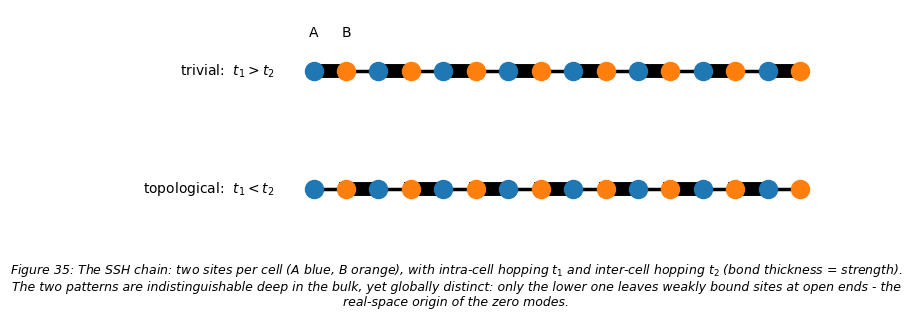

In [2]:
# --- geometry: the two dimerisation patterns of the SSH chain ----------------
import numpy as np
from matplotlib import pyplot

fig, axes = pyplot.subplots(2, 1, figsize=(9, 2.8), sharex=True)
for ax, (t1, t2, label) in zip(axes, [(1.0, 0.5, 'trivial:  $t_1 > t_2$'),
                                      (0.5, 1.0, 'topological:  $t_1 < t_2$')]):
    for n in range(8):
        xA, xB = 2 * n, 2 * n + 1
        ax.plot([xA, xB], [0, 0], 'k-', lw=10 * t1 * t1, solid_capstyle='round')
        if n < 7:
            ax.plot([xB, xB + 1], [0, 0], 'k-', lw=10 * t2 * t2)
        ax.plot(xA, 0, 'o', ms=13, color='C0', zorder=3)
        ax.plot(xB, 0, 'o', ms=13, color='C1', zorder=3)
    ax.text(-1.2, 0, label, va='center', ha='right', fontsize=10)
    ax.set_xlim(-6, 15.5)
    ax.set_ylim(-0.45, 0.75)
    ax.set_axis_off()
axes[0].text(0, .42, 'A', ha='center')
axes[0].text(1, .42, 'B', ha='center')
show_fig(r'The SSH chain: two sites per cell (A blue, B orange), with intra-cell hopping $t_1$ and inter-cell hopping $t_2$ (bond thickness = strength). The two patterns are indistinguishable deep in the bulk, yet globally distinct: only the lower one leaves weakly bound sites at open ends - the real-space origin of the zero modes.')

trivial      t1=1.0 t2=0.5:  winding = 0,  Zak phase = 0.0000 pi
topological  t1=0.5 t2=1.0:  winding = 1,  Zak phase = 1.0000 pi


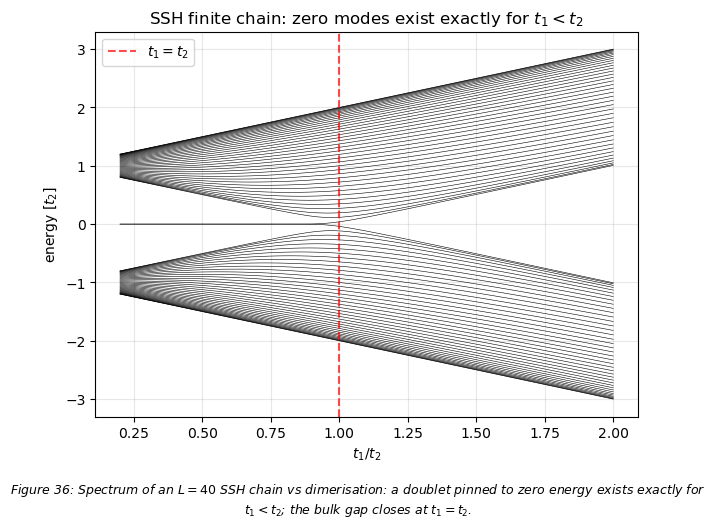

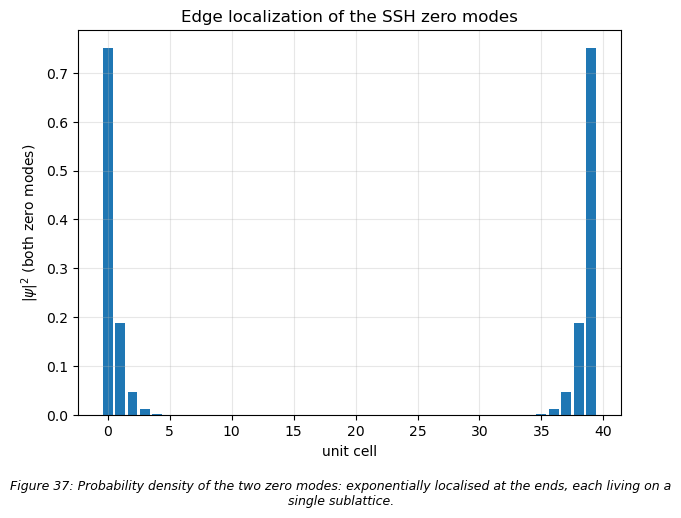

In [3]:
# --- SSH chain: winding number, Zak phase, and the edge-state doublet --------
import kwant, numpy as np
from matplotlib import pyplot

sigma_x = np.array([[0, 1], [1, 0]])
lat = kwant.lattice.chain(norbs=2)              # 2 orbitals = A/B sublattice
hop_inter = np.array([[0.0, 1.0], [0.0, 0.0]])  # B(x) -> A(x+1)

def ssh_chain(t1, t2, L):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = t1 * sigma_x
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = t2 * hop_inter
    return syst

def winding_number(t1, t2, nk=201):
    ks = np.linspace(0, 2 * np.pi, nk)
    q = t1 + t2 * np.exp(1j * ks)                       # det block of H(k)
    return int(round(np.diff(np.unwrap(np.angle(q))).sum() / (2 * np.pi)))

def zak_phase(t1, t2, nk=200):
    """Berry phase of the filled band: a discrete Wilson loop over the BZ."""
    ks = np.linspace(0, 2 * np.pi, nk, endpoint=False)
    us = []
    for k in ks:
        q = t1 + t2 * np.exp(1j * k)
        h = np.array([[0, q], [np.conj(q), 0]])
        us.append(np.linalg.eigh(h)[1][:, 0])
    prod = 1.0 + 0j
    for i in range(nk):
        prod *= np.vdot(us[i], us[(i + 1) % nk])
    return (-np.angle(prod)) % (2 * np.pi)

for (t1, t2), label in [((1.0, 0.5), "trivial"), ((0.5, 1.0), "topological")]:
    print(f"{label:12s} t1={t1} t2={t2}:  winding = {winding_number(t1, t2)},  "
          f"Zak phase = {zak_phase(t1, t2) / np.pi:.4f} pi")

# spectrum of a finite chain across the transition: watch the zero modes appear
L = 40
ratios = np.linspace(0.2, 2.0, 61)
spectra = []
for r in ratios:                                   # t1/t2 = r at fixed bandwidth
    h = ssh_chain(r, 1.0, L).finalized().hamiltonian_submatrix()
    spectra.append(np.linalg.eigvalsh(h))
spectra = np.array(spectra)

pyplot.plot(ratios, spectra, 'k-', lw=.4)
pyplot.axvline(1.0, color='r', ls='--', alpha=.7, label=r'$t_1 = t_2$')
pyplot.xlabel(r"$t_1 / t_2$"); pyplot.ylabel("energy $[t_2]$")
pyplot.title("SSH finite chain: zero modes exist exactly for $t_1 < t_2$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Spectrum of an $L=40$ SSH chain vs dimerisation: a doublet pinned to zero energy exists exactly for $t_1<t_2$; the bulk gap closes at $t_1=t_2$.')

# the zero modes live on the ends, one sublattice each
h = ssh_chain(0.5, 1.0, L).finalized().hamiltonian_submatrix()
ev, vec = np.linalg.eigh(h)
izero = np.argsort(np.abs(ev))[:2]
dens = (np.abs(vec[:, izero]) ** 2).sum(axis=1).reshape(L, 2).sum(axis=1)
pyplot.bar(range(L), dens, color='C0')
pyplot.xlabel("unit cell"); pyplot.ylabel(r"$|\psi|^2$ (both zero modes)")
pyplot.title("Edge localization of the SSH zero modes")
pyplot.grid(alpha=.3); show_fig(r'Probability density of the two zero modes: exponentially localised at the ends, each living on a single sublattice.')

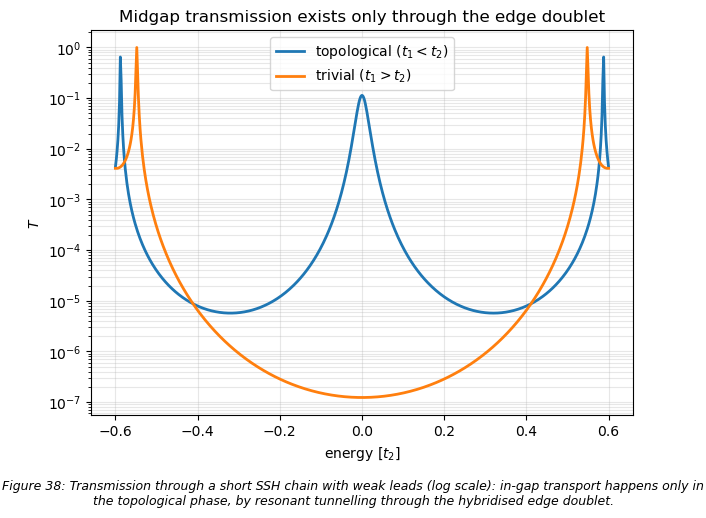

in-gap max T:  topological = 0.1136,  trivial = 6.52e-06


In [4]:
# --- SSH transport: resonant tunnelling through the edge doublet -------------
import kwant, numpy as np
from matplotlib import pyplot

sigma_x = np.array([[0, 1], [1, 0]])
lat = kwant.lattice.chain(norbs=2)
hop_inter = np.array([[0.0, 1.0], [0.0, 0.0]])

def ssh_transport(t1, t2, L=8, t_c=0.15):
    """Short SSH chain, weak links t_c to metallic contacts, uniform-chain leads."""
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = t1 * sigma_x
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = t2 * hop_inter
    syst[lat(-1)] = 1.0 * sigma_x                 # metallic contact cells
    syst[lat(L)] = 1.0 * sigma_x
    syst[lat(0), lat(-1)] = t_c * hop_inter       # the weak links
    syst[lat(L), lat(L - 1)] = t_c * hop_inter
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)))
    lead[lat(0)] = 1.0 * sigma_x                  # t1 = t2: gapless = metallic
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = hop_inter
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

energies = np.linspace(-0.6, 0.6, 601)
T_top = [kwant.smatrix(ssh_transport(0.5, 1.0), e).transmission(1, 0)
         for e in energies]
T_tri = [kwant.smatrix(ssh_transport(1.0, 0.5), e).transmission(1, 0)
         for e in energies]

pyplot.semilogy(energies, T_top, lw=2, label=r"topological ($t_1 < t_2$)")
pyplot.semilogy(energies, T_tri, lw=2, label=r"trivial ($t_1 > t_2$)")
pyplot.xlabel("energy $[t_2]$"); pyplot.ylabel(r"$T$")
pyplot.title("Midgap transmission exists only through the edge doublet")
pyplot.legend(); pyplot.grid(alpha=.3, which='both'); show_fig(r'Transmission through a short SSH chain with weak leads (log scale): in-gap transport happens only in the topological phase, by resonant tunnelling through the hybridised edge doublet.')

gap = np.abs(energies) < 0.4                  # strictly inside both gaps
Tg_top, Tg_tri = np.array(T_top)[gap].max(), np.array(T_tri)[gap].max()
print(f"in-gap max T:  topological = {Tg_top:.4f},  trivial = {Tg_tri:.2e}")
assert Tg_top > 30 * Tg_tri

---
## 18. The Kitaev chain — Majorana zero modes

Kitaev's model [Phys.-Usp. **44**, 131 (2001)] is a spinless 1D $p$-wave
superconductor.  In the BdG basis $(c, c^\dagger)$,

$$H(k) = \underbrace{(-\mu - 2t\cos k)}_{h(k)}\,\tau_z +
         \underbrace{2\Delta \sin k}_{d(k)}\,\tau_y ,$$

with spectrum $E(k) = \pm\sqrt{h^2 + d^2}$.  Particle–hole symmetry
($P = \tau_x K$, $P H(k) P^{-1} = -H(-k)$) protects a $\mathbb{Z}_2$
invariant that only depends on the signs of $h$ at the PH-symmetric momenta:

$$Q = \operatorname{sign}\left[h(0)\,h(\pi)\right] =
\operatorname{sign}\left[\mu^2 - 4t^2\right],$$

so the chain is **topological for $|\mu| < 2t$**.  There it hosts one Majorana
zero mode per end ($\gamma = \gamma^\dagger$), split only by an exponentially
small overlap.

The experimental smoking gun is transport: an electron incident from a normal
lead *must* Andreev-reflect resonantly through the Majorana, pinning the
zero-bias conductance to exactly $2e^2/h$ — independent of the barrier
strength.  This is the cleanest quantization in this notebook after the
conductance staircase of Part I.  (See topocondmat.org, week 1–2.)

**Physics in more depth.**  The chain belongs to class D: only particle-hole
symmetry, giving a $\mathbb{Z}_2$ invariant — the sign of the Pfaffian of
$H(k)$ at the two PH-symmetric momenta, which reduces to the
$\operatorname{sign}[h(0)h(\pi)]$ used below.  What makes Majorana end modes
more than a curiosity is their **non-abelian exchange statistics**: braiding
two of them enacts a unitary rotation in the degenerate ground-state
manifold [Ivanov, PRL **86**, 268 (2001)], the basis of topological quantum
computation proposals [Kitaev, Ann. Phys. **303**, 2 (2003)].  The ZBP
computed below is the transport face of a deeper statement: PH symmetry
forces the reflection matrix determinant to $\pm1$, and the topological
sign pins perfect Andreev reflection at $E=0$.

*Reviews:* Alicea, Rep. Prog. Phys. **75**, 076501 (2012); Beenakker, Annu.
Rev. Condens. Matter Phys. **4**, 113 (2013); Leijnse & Flensberg, Semicond.
Sci. Technol. **27**, 124003 (2012).


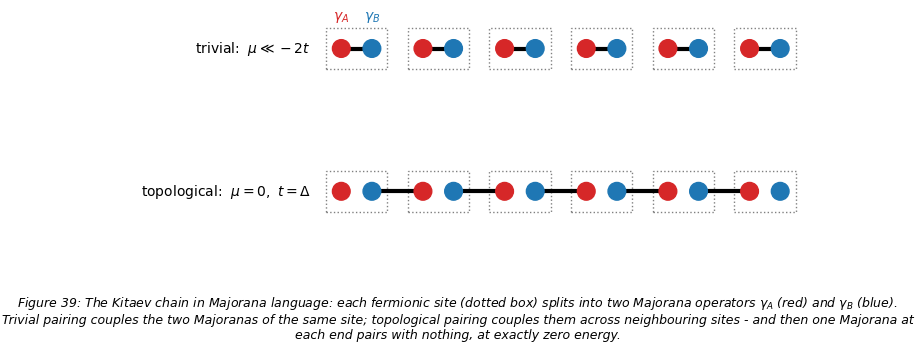

In [5]:
# --- geometry: the Kitaev chain in the Majorana representation ---------------
import numpy as np
from matplotlib import pyplot

fig, axes = pyplot.subplots(2, 1, figsize=(9, 3.4))
for ax, (pair, label) in zip(axes,
                             [('intra', 'trivial:  $\\mu \\ll -2t$'),
                              ('inter', 'topological:  $\\mu = 0,\\ t = \\Delta$')]):
    for n in range(6):
        x = 2.4 * n
        ax.add_patch(pyplot.Rectangle((x - 0.45, -0.6), 1.8, 1.2, fill=False,
                                      ls=':', ec='gray'))
        if pair == 'intra':
            ax.plot([x, x + 0.9], [0, 0], 'k-', lw=3, zorder=2)
        elif n < 5:
            ax.plot([x + 0.9, x + 2.4], [0, 0], 'k-', lw=3, zorder=2)
        ax.add_patch(pyplot.Circle((x, 0), 0.26, color='C3', zorder=3))
        ax.add_patch(pyplot.Circle((x + 0.9, 0), 0.26, color='C0', zorder=3))
    ax.text(-0.9, 0, label, va='center', ha='right', fontsize=10)
    ax.set_xlim(-6.5, 14)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_axis_off()
axes[0].text(0, 0.85, r'$\gamma_A$', color='C3', ha='center')
axes[0].text(0.9, 0.85, r'$\gamma_B$', color='C0', ha='center')
show_fig(r'The Kitaev chain in Majorana language: each fermionic site (dotted box) splits into two Majorana operators $\gamma_A$ (red) and $\gamma_B$ (blue). Trivial pairing couples the two Majoranas of the same site; topological pairing couples them across neighbouring sites - and then one Majorana at each end pairs with nothing, at exactly zero energy.')

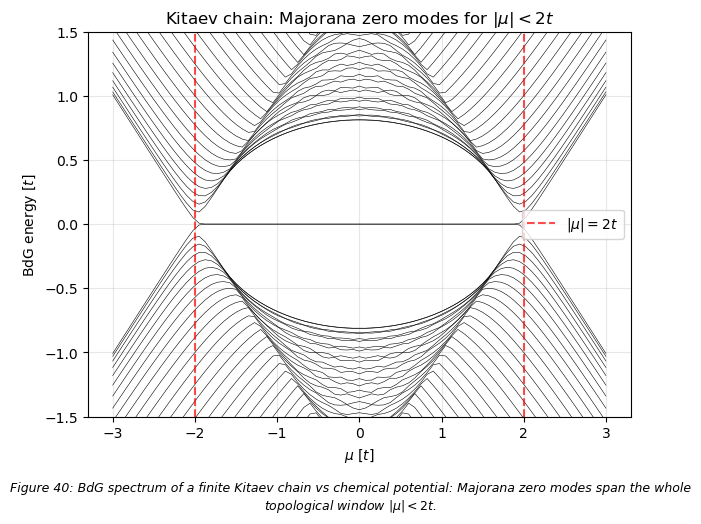

Q(mu=0.5) = -1  (topological);  Q(mu=3.0) = 1  (trivial)
L= 10:  |E_0| = 1.60e-02
L= 20:  |E_0| = 2.06e-04
L= 40:  |E_0| = 1.58e-08


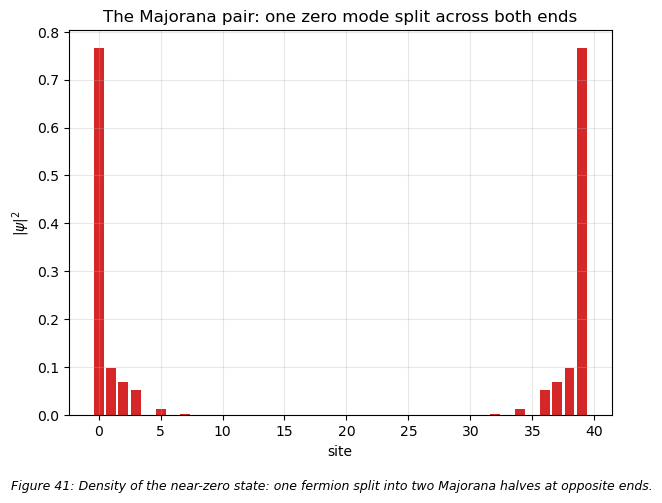

In [6]:
# --- Kitaev chain: phase diagram and Majorana modes ---------------------------
import kwant, numpy as np
from matplotlib import pyplot

tau_y = np.array([[0, -1j], [1j, 0]])
tau_z = np.array([[1, 0], [0, -1]])

t, Delta = 1.0, 0.4
lat = kwant.lattice.chain(norbs=2)          # 2 orbitals = particle, hole

def kitaev_chain(mu, L):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = -mu * tau_z
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = \
        -t * tau_z - 1j * Delta * tau_y
    return syst

# spectrum of a finite chain vs mu: Majoranas exist exactly for |mu| < 2t
L = 40
mus = np.linspace(-3, 3, 81)
spectra = np.array([np.linalg.eigvalsh(
    kitaev_chain(m, L).finalized().hamiltonian_submatrix()) for m in mus])

pyplot.plot(mus, spectra, 'k-', lw=.4)
pyplot.axvline(-2, color='r', ls='--', alpha=.7)
pyplot.axvline(2, color='r', ls='--', alpha=.7, label=r'$|\mu| = 2t$')
pyplot.ylim(-1.5, 1.5)
pyplot.xlabel(r"$\mu\ [t]$"); pyplot.ylabel("BdG energy $[t]$")
pyplot.title("Kitaev chain: Majorana zero modes for $|\\mu| < 2t$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'BdG spectrum of a finite Kitaev chain vs chemical potential: Majorana zero modes span the whole topological window $|\mu|<2t$.')

# the Z2 invariant needs only the signs of h(k) at k = 0 and pi
Q = lambda mu: int(np.sign((-mu - 2 * t) * (-mu + 2 * t)))
print("Q(mu=0.5) =", Q(0.5), " (topological);  Q(mu=3.0) =", Q(3.0), " (trivial)")

# exponential protection: the zero-mode splitting vs chain length
for L_ in (10, 20, 40):
    ev = np.linalg.eigvalsh(kitaev_chain(0.5, L_).finalized()
                            .hamiltonian_submatrix())
    print(f"L={L_:3d}:  |E_0| = {np.abs(ev).min():.2e}")

# Majorana wavefunction: half a fermion on each end
h = kitaev_chain(0.5, L).finalized().hamiltonian_submatrix()
ev, vec = np.linalg.eigh(h)
izero = np.argsort(np.abs(ev))[:2]
dens = (np.abs(vec[:, izero]) ** 2).sum(axis=1).reshape(L, 2).sum(axis=1)
pyplot.bar(range(L), dens, color='C3')
pyplot.xlabel("site"); pyplot.ylabel(r"$|\psi|^2$")
pyplot.title("The Majorana pair: one zero mode split across both ends")
pyplot.grid(alpha=.3); show_fig(r'Density of the near-zero state: one fermion split into two Majorana halves at opposite ends.')

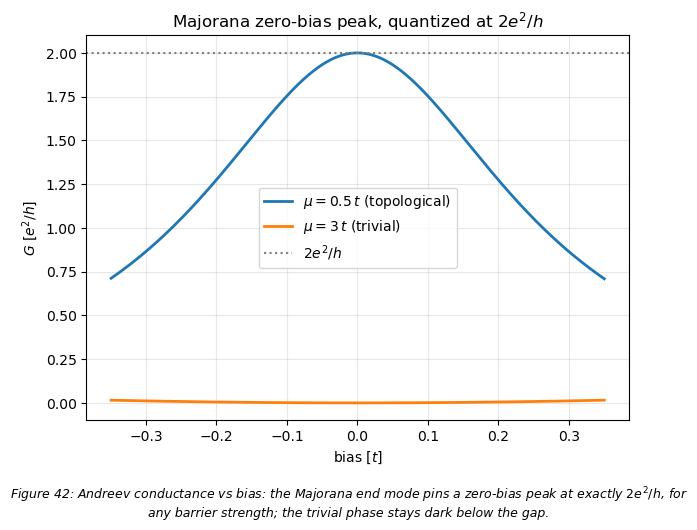

barrier=1.0:  G(V~0) = 2.000000  (pinned to 2 by the Majorana)
barrier=1.6:  G(V~0) = 2.000000  (pinned to 2 by the Majorana)
barrier=2.5:  G(V~0) = 1.999999  (pinned to 2 by the Majorana)


In [7]:
# --- NS junction: the quantized zero-bias peak --------------------------------
import kwant, numpy as np
from matplotlib import pyplot

tau_x = np.array([[0, 1], [1, 0]])
tau_y = np.array([[0, -1j], [1j, 0]])
tau_z = np.array([[1, 0], [0, -1]])
t, Delta = 1.0, 0.4
lat = kwant.lattice.chain(norbs=2)

def ns_kitaev(mu_wire, L=25, mu_lead=1.0, barrier=1.6):
    """normal lead | tunnel barrier | Kitaev chain (far end terminated)."""
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = -mu_wire * tau_z
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = \
        -t * tau_z - 1j * Delta * tau_y
    syst[lat(0)] = (-mu_wire + barrier) * tau_z
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)),
                         conservation_law=-tau_z, particle_hole=tau_x)
    lead[lat(0)] = -mu_lead * tau_z
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = -t * tau_z
    syst.attach_lead(lead)
    return syst.finalized()

def andreev_G(fsyst, e):
    """G = N - R_ee + R_he, in units e^2/h (one lead: reflection only)."""
    s = kwant.smatrix(fsyst, e)
    N = s.submatrix((0, 0), (0, 0)).shape[0]
    return N - s.transmission((0, 0), (0, 0)) + s.transmission((0, 1), (0, 0))

# NB: at exactly E = 0 the electron and hole modes of a PH-symmetric lead are
# degenerate and the block labelling is singular -- never evaluate there.
energies = np.linspace(-0.35, 0.35, 281) + 5e-4
G_top = [andreev_G(ns_kitaev(0.5), e) for e in energies]
G_tri = [andreev_G(ns_kitaev(3.0), e) for e in energies]

pyplot.plot(energies, G_top, lw=2, label=r"$\mu = 0.5\,t$ (topological)")
pyplot.plot(energies, G_tri, lw=2, label=r"$\mu = 3\,t$ (trivial)")
pyplot.axhline(2, color='gray', ls=':', label=r'$2e^2/h$')
pyplot.xlabel("bias $[t]$"); pyplot.ylabel(r"$G\ [e^2/h]$")
pyplot.title("Majorana zero-bias peak, quantized at $2e^2/h$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Andreev conductance vs bias: the Majorana end mode pins a zero-bias peak at exactly $2e^2/h$, for any barrier strength; the trivial phase stays dark below the gap.')

for barrier in (1.0, 1.6, 2.5):
    G0 = andreev_G(ns_kitaev(0.5, barrier=barrier), 1e-4)
    print(f"barrier={barrier}:  G(V~0) = {G0:.6f}  (pinned to 2 by the Majorana)")
    assert abs(G0 - 2.0) < 1e-3

---
## 19. The Majorana nanowire — Kitaev physics in a real device

No spinless $p$-wave superconductors exist in nature.  Oreg *et al.* [PRL
**105**, 177002 (2010)] and Lutchyn *et al.* [PRL **105**, 077001 (2010)]
showed how to engineer one: a semiconductor wire with Rashba spin–orbit
coupling $\alpha$, proximitized by an $s$-wave superconductor $\Delta$, in a
magnetic field $B$ along the wire.  In the Nambu basis
$(\psi_\uparrow, \psi_\downarrow, \psi_\downarrow^\dagger, -\psi_\uparrow^\dagger)$:

$$H = \left(\frac{k^2}{2m} - \mu + \alpha k \sigma_y\right)\tau_z
      + B\,\sigma_x + \Delta\,\tau_x .$$

The Zeeman term opens a helical gap; pairing then drives the wire into an
effective Kitaev phase when

$$B > B_c = \sqrt{\Delta^2 + \mu^2},$$

with the bulk gap closing and reopening exactly at $B_c$.  The signature is
the same as for the Kitaev chain — a zero-bias conductance peak at $2e^2/h$ —
but now it *emerges as the field is tuned through* $B_c$, which is what the
2012 Delft experiment [Mourik *et al.*, Science **336**, 1003] looked for.
(See topocondmat.org, week 2.)

**Experimental status — read with care.**  The first zero-bias peaks were
reported by Mourik *et al.* [Science **336**, 1003 (2012)] and refined in
hard-gap devices [Deng *et al.*, Science **354**, 1557 (2016)].  But a ZBP
alone is *not* proof of a Majorana: disorder, smooth confinement and Andreev
bound states can all pin peaks near zero bias without any topology — one
prominent "quantised" claim was retracted.  The field's sobering
self-assessment is in Prada *et al.*, Nat. Rev. Phys. **2**, 575 (2020) and
Flensberg, von Oppen & Stern, Nat. Rev. Mater. **6**, 944 (2021); a
measurement protocol that goes beyond single-peak evidence is described in
Microsoft Quantum, PRB **107**, 245423 (2023).  Simulations like the one
below are the baseline against which such claims are judged.


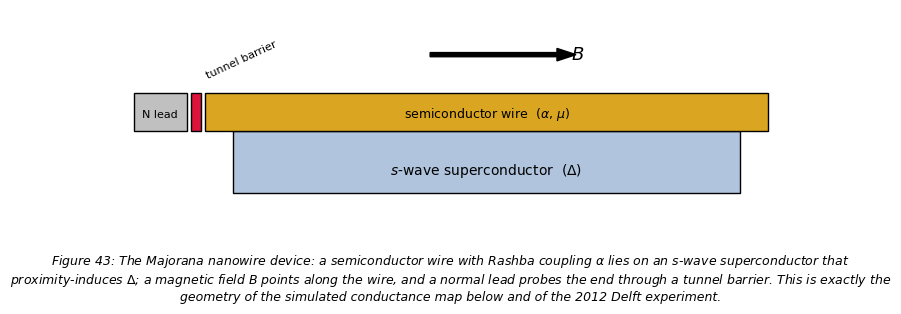

In [8]:
# --- geometry: the hybrid nanowire device ------------------------------------
from matplotlib import pyplot
from matplotlib.patches import FancyArrow, Rectangle

fig, ax = pyplot.subplots(figsize=(9, 2.7))
ax.add_patch(Rectangle((1.4, 0.35), 7.2, 0.9, fc='#b0c4de', ec='k'))
ax.add_patch(Rectangle((1.0, 1.25), 8.0, 0.55, fc='#daa520', ec='k'))
ax.add_patch(Rectangle((0.0, 1.25), 0.75, 0.55, fc='#c0c0c0', ec='k'))
ax.add_patch(Rectangle((0.80, 1.25), 0.15, 0.55, fc='crimson', ec='k'))
ax.add_patch(FancyArrow(4.2, 2.35, 1.8, 0, width=0.06, color='k'))
ax.text(6.2, 2.35, '$B$', fontsize=13, va='center')
ax.text(5.0, 0.62, r'$s$-wave superconductor  ($\Delta$)', ha='center')
ax.text(5.0, 1.44, r'semiconductor wire  ($\alpha$, $\mu$)',
        ha='center', fontsize=9)
ax.text(0.37, 1.44, 'N lead', ha='center', fontsize=8)
ax.text(1.0, 2.0, 'tunnel barrier', fontsize=8, rotation=25)
ax.set_xlim(-0.3, 9.6)
ax.set_ylim(0, 3.0)
ax.set_axis_off()
show_fig(r'The Majorana nanowire device: a semiconductor wire with Rashba coupling $\alpha$ lies on an s-wave superconductor that proximity-induces $\Delta$; a magnetic field B points along the wire, and a normal lead probes the end through a tunnel barrier. This is exactly the geometry of the simulated conductance map below and of the 2012 Delft experiment.')

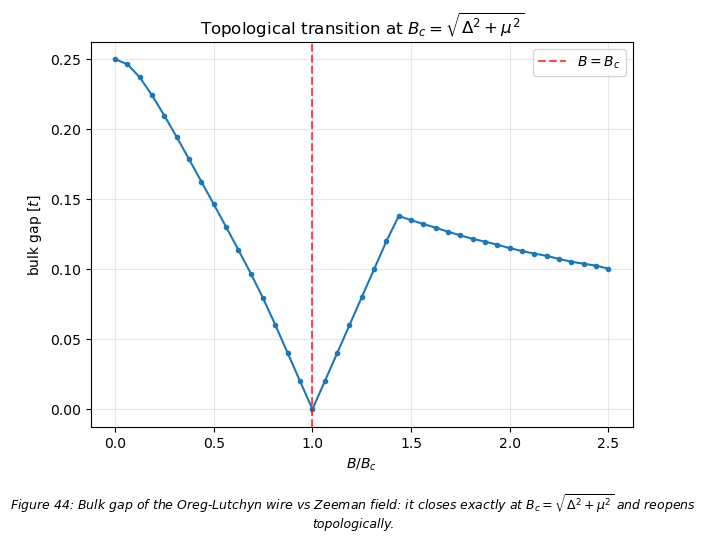

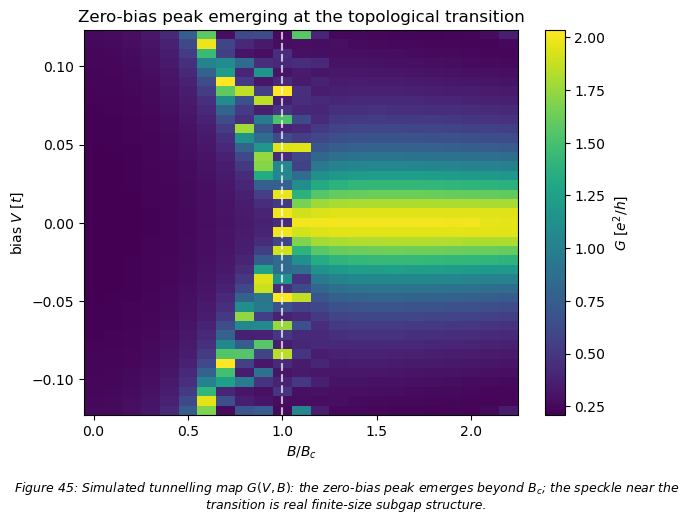

G(V~0):  B=0.5 B_c -> 0.251;   B=1.8 B_c -> 2.0000  (2 = Majorana)


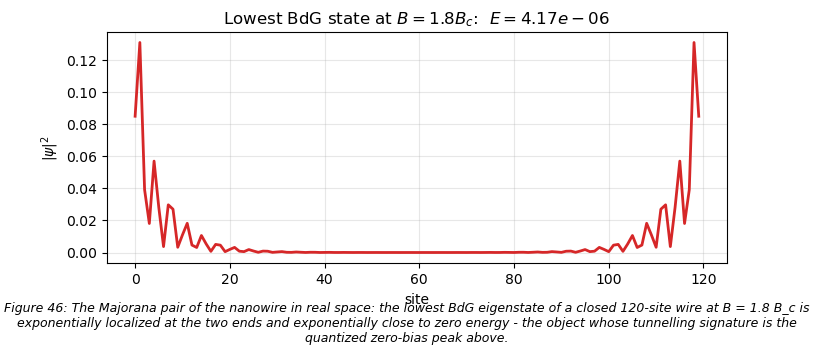

In [9]:
# --- Majorana nanowire: gap closing at B_c and the emerging ZBP ---------------
import kwant, numpy as np
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
k4 = np.kron

t, alpha, Delta, mu = 1.0, 0.4, 0.25, 0.2
Bc = np.hypot(Delta, mu)
lat = kwant.lattice.chain(norbs=4)          # (up, dn) x (particle, hole)

def onsite(B):
    return (2 * t - mu) * k4(sz, s0) + B * k4(np.eye(2), sx) + Delta * k4(sx, s0)

hopping = -t * k4(sz, s0) + 0.5j * alpha * k4(sz, sy)

def wire_lead(B):
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)))
    lead[lat(0)] = onsite(B)
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = hopping
    return lead

# (a) bulk gap vs B: closes exactly at B_c = sqrt(Delta^2 + mu^2)
Bs = np.linspace(0, 2.5 * Bc, 41)
ks = np.linspace(0, np.pi, 201)
gaps = []
for B in Bs:
    bands = kwant.physics.Bands(wire_lead(B).finalized())
    gaps.append(min(np.abs(bands(k)).min() for k in ks))

pyplot.plot(Bs / Bc, gaps, 'o-', ms=3)
pyplot.axvline(1, color='r', ls='--', alpha=.7, label=r'$B = B_c$')
pyplot.xlabel(r"$B / B_c$"); pyplot.ylabel("bulk gap $[t]$")
pyplot.title(r"Topological transition at $B_c=\sqrt{\Delta^2+\mu^2}$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Bulk gap of the Oreg-Lutchyn wire vs Zeeman field: it closes exactly at $B_c=\sqrt{\Delta^2+\mu^2}$ and reopens topologically.')

# (b) tunneling conductance map G(V, B): the ZBP appears only above B_c
def ns_wire(B, L=70, barrier=1.2, mu_lead=1.5):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = onsite(B)
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = hopping
    syst[lat(0)] = onsite(B) + barrier * k4(sz, s0)
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)),
                         conservation_law=-k4(sz, s0))
    lead[lat(0)] = (2 * t - mu_lead) * k4(sz, s0) + B * k4(np.eye(2), sx)
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = -t * k4(sz, s0)
    syst.attach_lead(lead)
    return syst.finalized()

def andreev_G(fsyst, e):
    s = kwant.smatrix(fsyst, e)
    N = s.submatrix((0, 0), (0, 0)).shape[0]
    return N - s.transmission((0, 0), (0, 0)) + s.transmission((0, 1), (0, 0))

Bs_map = np.linspace(0, 2.2 * Bc, 23)
Vs = np.linspace(-0.12, 0.12, 41) + 2e-4
Gmap = np.array([[andreev_G(ns_wire(B), V) for B in Bs_map] for V in Vs])

pyplot.pcolormesh(Bs_map / Bc, Vs, Gmap, shading='auto', cmap='viridis')
pyplot.colorbar(label=r"$G\ [e^2/h]$")
pyplot.axvline(1, color='w', ls='--', alpha=.7)
pyplot.xlabel(r"$B/B_c$"); pyplot.ylabel("bias $V$ $[t]$")
pyplot.title("Zero-bias peak emerging at the topological transition")
show_fig(r'Simulated tunnelling map $G(V,B)$: the zero-bias peak emerges beyond $B_c$; the speckle near the transition is real finite-size subgap structure.')

G_below = andreev_G(ns_wire(0.5 * Bc), 1e-4)
G_above = andreev_G(ns_wire(1.8 * Bc), 1e-4)
print(f"G(V~0):  B=0.5 B_c -> {G_below:.3f};   B=1.8 B_c -> {G_above:.4f}  (2 = Majorana)")
assert abs(G_above - 2.0) < 0.05

# the Majorana pair in real space: lowest BdG state of a long closed wire
L_mzm = 120
wire_cl = kwant.Builder()
wire_cl[(lat(x) for x in range(L_mzm))] = onsite(1.8 * Bc)
wire_cl[kwant.builder.HoppingKind((1,), lat, lat)] = hopping
evw, vecw = np.linalg.eigh(wire_cl.finalized().hamiltonian_submatrix())
i0 = np.argmin(np.abs(evw))
dens_mzm = (np.abs(vecw[:, i0]) ** 2).reshape(L_mzm, 4).sum(axis=1)
pyplot.figure(figsize=(8, 3))
pyplot.plot(dens_mzm, lw=2, color='C3')
pyplot.xlabel('site'); pyplot.ylabel(r'$|\psi|^2$')
pyplot.title(f'Lowest BdG state at $B = 1.8B_c$:  $E = {evw[i0]:.2e}$')
pyplot.grid(alpha=.3)
show_fig(r'The Majorana pair of the nanowire in real space: the lowest BdG eigenstate of a closed 120-site wire at B = 1.8 B_c is exponentially localized at the two ends and exponentially close to zero energy - the object whose tunnelling signature is the quantized zero-bias peak above.')